## Imports

In [1]:
from LQR import *
from DGM import *
from FNN import *
from PDE_Solve_dgm import *
from Policy_Iteration import *

## Problem Setup

We use the following matrices throughout the coursework:

$$H = \begin{pmatrix}1 & 0.5 \\ 0 & 1\end{pmatrix}, \quad M = C = D = R = I_2, \quad \sigma = 0.5 I_2, \quad T = 1$$

In [2]:
H = np.array([[1.0, 0.5], [0.0, 1.0]])
M = np.array([[1.0, 0.0], [0.0, 1.0]])
C = np.array([[1.0, 0.0], [0.0, 1.0]])
D = np.array([[1.0, 0.0], [0.0, 1.0]])
R = np.array([[1.0, 0.0], [0.0, 1.0]])
sigma = np.array([[0.5, 0.0], [0.0, 0.5]])
T = 1.0

lqr = LQR(H, M, C, D, R, sigma, T)

---
## Exercise 1.1: Riccati ODE Solution

We solve the Riccati ODE backwards from $S(T) = R$ and evaluate the benchmark value function
$v(t,x) = x^\top S(t) x + \int_t^T \mathrm{tr}(\sigma\sigma^\top S(r))\,dr$
and optimal control $a(t,x) = -D^{-1}M^\top S(t)x$ at three test points.

At $t=T$ we expect $v(T,x) = x^\top R x$ and $a(T,x) = -M^\top R x$ exactly.

In [7]:
time_grid = np.linspace(0, T, 500)
lqr.Sol_Ricatti(time_grid)

t_test = torch.tensor([0.0, 0.5, 1.0], dtype=torch.float32)
x_test = torch.tensor([[[1.0, 1.0]],[[0.0, 1.0]],[[1.0, 2.0]]],dtype=torch.float32)

v = lqr.Sol_value(t_test, x_test)
a = lqr.control(t_test, x_test)

print("\n Value function v(t, x):")
for i in range(len(t_test)):
    print(f"t={t_test[i].item():.1f}, x={x_test[i,0,:].tolist()} -> v={v[i].item():.4f}")

print("\n Optimal control a(t, x):")
for i in range(len(t_test)):
    a_i = a[i].tolist()
    a_str = f"[{a_i[0]:.4f}, {a_i[1]:.4f}]"
    print(f"t={t_test[i].item():.1f}, x={x_test[i,0,:].tolist()} -> a={a_str}")


 Value function v(t, x):
t=0.0, x=[1.0, 1.0] -> v=6.2425
t=0.5, x=[0.0, 1.0] -> v=2.2742
t=1.0, x=[1.0, 2.0] -> v=5.0000

 Optimal control a(t, x):
t=0.0, x=[1.0, 1.0] -> a=[-2.6109, -2.7355]
t=0.5, x=[0.0, 1.0] -> a=[-0.2771, -1.9066]
t=1.0, x=[1.0, 2.0] -> a=[-1.0000, -2.0000]


---
## Exercise 1.2: Monte Carlo Convergence Checks

We use the **explicit Euler scheme** to simulate the optimally controlled SDE and estimate $v(0, (1,1)^\top)$.

**Error metric:** absolute error $|v_{MC} - v|$, where $v$ is the Riccati benchmark.
This directly measures the bias from time discretisation (Plot 1) and the variance of the MC estimator (Plot 2).

**Expected rates:**
- Plot 1 (vary $N$, fix $M=10^5$): $O(1/N)$ from the explicit Euler scheme
- Plot 2 (vary $M$, fix $N=5000$): $O(1/\sqrt{M})$ from the Central Limit Theorem

Benchmark value v(t,x) = 6.242467
N_steps=    1, mean abs error=1.1112e+01
N_steps=   10, mean abs error=3.8545e-01
N_steps=   50, mean abs error=6.8353e-02
N_steps=  100, mean abs error=3.8027e-02
N_steps=  500, mean abs error=9.9926e-03
N_steps= 1000, mean abs error=4.9026e-03
N_steps= 5000, mean abs error=4.6464e-03
N_samples=    10, mean abs error=2.9838e-01
N_samples=    50, mean abs error=2.8148e-01
N_samples=   100, mean abs error=9.0514e-02
N_samples=   500, mean abs error=1.0339e-01
N_samples=  1000, mean abs error=5.3842e-02
N_samples=  5000, mean abs error=1.7643e-02
N_samples= 10000, mean abs error=2.2031e-02
N_samples= 50000, mean abs error=7.5012e-03
N_samples=100000, mean abs error=6.8227e-03


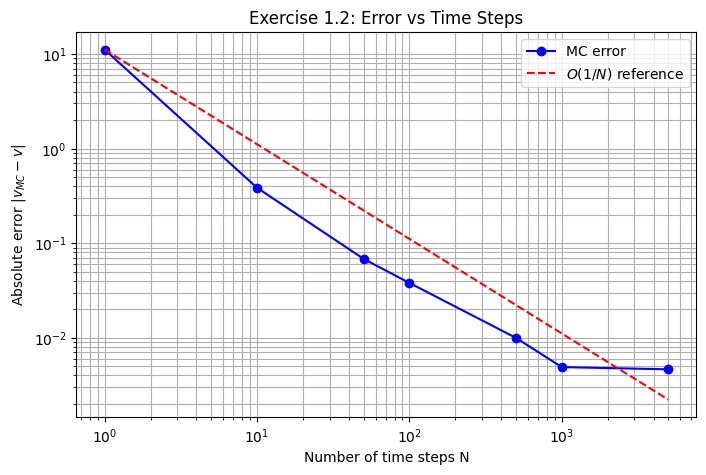

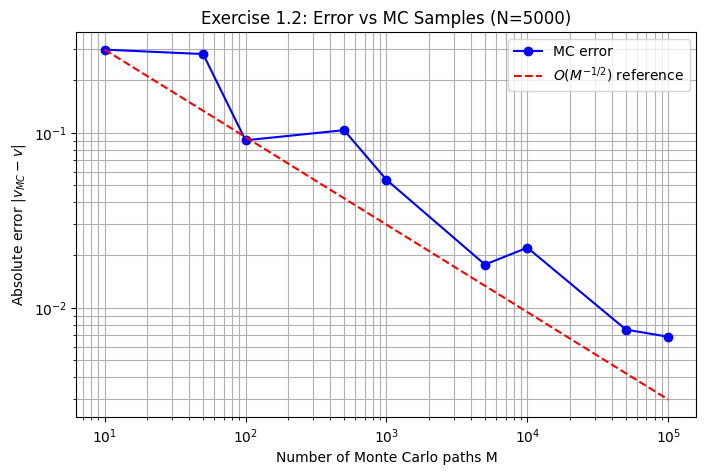

{'v_exact': 6.242466926574707,
 'steps_list': [1, 10, 50, 100, 500, 1000, 5000],
 'errors_steps': [11.11176243752303,
  0.3854542582432405,
  0.06835346777774891,
  0.03802710374309566,
  0.009992557869520979,
  0.004902613983965409,
  0.004646367264106921],
 'samples_list': [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000],
 'errors_samples': [0.2983848027651378,
  0.2814833370075256,
  0.09051417922179787,
  0.10339132745808718,
  0.05384177483293566,
  0.017642640183798262,
  0.022031346281189988,
  0.007501202933138984,
  0.006822670801457598]}

In [14]:
lqr.error_analysis(
    t=0.0,
    x=np.array([1.0, 1.0]),
    steps_list=[1, 10, 50, 100, 500, 1000, 5000],
    samples_list=[10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000],
    fixed_paths=100000,
    fixed_steps=5000,
    repetitions=5,
    seed=1234)

---
## Exercise 2.1: Supervised Learning of Value Function

We train a `Net_DGM` network (hidden size 100) to approximate $v(t,x)$ using labels from Exercise 1.1.
Training data: $t \sim \mathrm{Uniform}[0,T]$, $x \sim \mathrm{Uniform}[-3,3]^2$.

The trained network is saved as `value_net` for use as a warm start in Exercise 4.1.

Epoch 0/1000, loss=189.239883
Epoch 100/1000, loss=1.821342
Epoch 200/1000, loss=0.678711
Epoch 300/1000, loss=0.343174
Epoch 400/1000, loss=0.116123
Epoch 500/1000, loss=0.070607
Epoch 600/1000, loss=0.035747
Epoch 700/1000, loss=0.048023
Epoch 800/1000, loss=0.023277
Epoch 900/1000, loss=0.013306


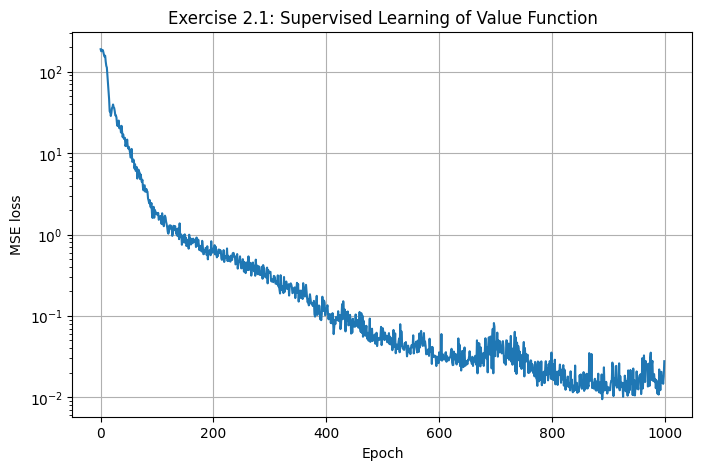

In [5]:
value_net, _ = train_value_network(lqr, n_epochs=1000, batch_size=1024, lr=1e-3)

---
## Exercise 2.2: Supervised Learning of Markov Control

We train an `FFN` network (2 hidden layers of size 100) to approximate $a(t,x)$ using labels from Exercise 1.1.
The output is 2-dimensional since $a \in \mathbb{R}^2$.

The trained network is saved as `control_net` for use as a warm start in Exercise 4.1.

Epoch 0/1000, loss=9.5429
Epoch 100/1000, loss=0.5856
Epoch 200/1000, loss=0.0911
Epoch 300/1000, loss=0.0546
Epoch 400/1000, loss=0.0467
Epoch 500/1000, loss=0.0430
Epoch 600/1000, loss=0.0399
Epoch 700/1000, loss=0.0360
Epoch 800/1000, loss=0.0289
Epoch 900/1000, loss=0.0222


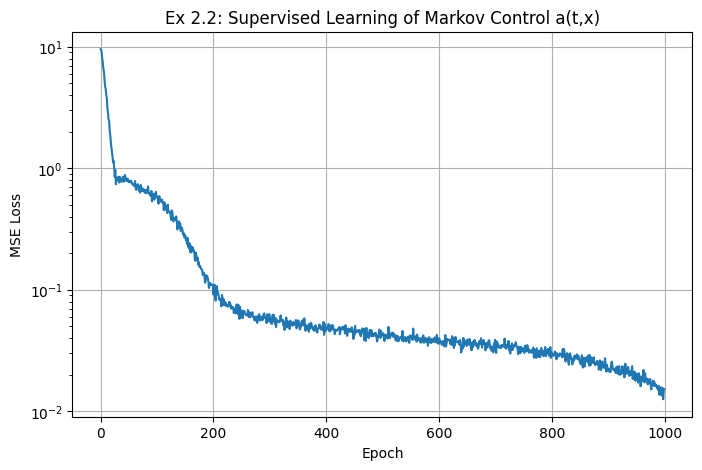

In [6]:
control_net, _ = train_control_network(lqr, n_epochs=1000, batch_size=1024, lr=1e-3)

---
## Exercise 3.1: Deep Galerkin Method for the Linear PDE

We solve the linear PDE corresponding to constant control $\alpha = (1,1)^\top$:

$$\partial_t u + \tfrac{1}{2}\mathrm{tr}(\sigma\sigma^\top \partial_{xx} u) + (\partial_x u)^\top H x + (\partial_x u)^\top M\alpha + x^\top C x + \alpha^\top D\alpha = 0$$

with terminal condition $u(T,x) = x^\top R x$.

The total loss is $\mathcal{L} = \mathcal{L}_{\text{pde}} + \mathcal{L}_{\text{boundary}}$.
The MC benchmark reuses the Exercise 1.2 simulation with constant control.

Epoch 0/1000 | total=124.273239 | pde=71.826027 | boundary=52.447212 | lr=1.00e-03
  -> mean MC benchmark error on fixed validation set = 2.9197e+01
Epoch 100/1000 | total=4.258539 | pde=2.604078 | boundary=1.654461 | lr=1.00e-03
Epoch 200/1000 | total=0.474287 | pde=0.230337 | boundary=0.243950 | lr=1.00e-03
  -> mean MC benchmark error on fixed validation set = 1.2090e+01
Epoch 300/1000 | total=0.283338 | pde=0.186592 | boundary=0.096747 | lr=1.00e-03
Epoch 400/1000 | total=0.166560 | pde=0.082239 | boundary=0.084320 | lr=5.00e-04
Epoch 500/1000 | total=0.127743 | pde=0.059108 | boundary=0.068634 | lr=5.00e-04
  -> mean MC benchmark error on fixed validation set = 1.0532e+01
Epoch 600/1000 | total=0.115378 | pde=0.069959 | boundary=0.045419 | lr=5.00e-04
Epoch 700/1000 | total=0.086838 | pde=0.043366 | boundary=0.043472 | lr=2.50e-04
  -> mean MC benchmark error on fixed validation set = 1.0221e+01
Epoch 800/1000 | total=0.049380 | pde=0.027484 | boundary=0.021896 | lr=2.50e-04
Epoch

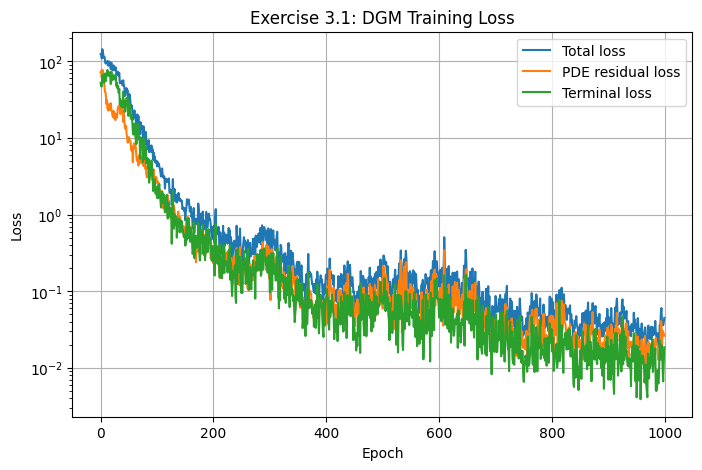

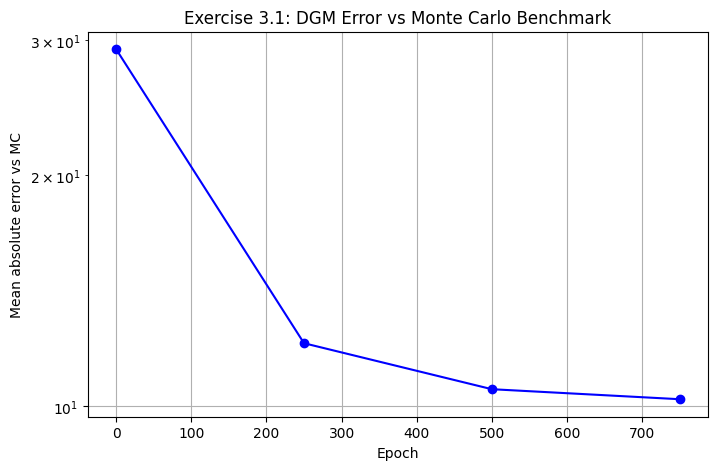

Final total loss:    0.0450
Final MC error:      1.0221e+01


In [9]:
net_pde, history_pde = train_dgm_linear_pde(lqr, n_epochs=1000, batch_size=128, lr=1e-3, eval_every=250)

print(f"Final total loss:    {history_pde['losses'][-1]:.4f}")
print(f"Final MC error:      {history_pde['mc_errors'][-1]:.4e}")

---
## Exercise 4.1: Policy Iteration with DGM

At each iteration:
1. **Value update** – fix `control_net`, train `value_net` by minimising the PDE residual + terminal loss
2. **Control update** – fix `value_net`, train `control_net` by minimising the Hamiltonian

We use the networks from Exercises 2.1 and 2.2 as warm starts.
After each iteration we compare with the Exercise 1.1 benchmark on a fixed test set.

Using Exercise 2.1 value network as the initial guess for policy iteration.
Using Exercise 2.2 control network as the initial guess for policy iteration.

Policy iteration 1/5
  [Value] epoch 0/300, total=1.681652, pde=1.642830, boundary=0.038822, lr=1.00e-03
  [Value] epoch 60/300, total=2.450540, pde=2.307229, boundary=0.143311, lr=1.00e-03
  [Value] epoch 120/300, total=1.515128, pde=1.274860, boundary=0.240268, lr=1.00e-03
  [Value] epoch 180/300, total=0.692561, pde=0.605679, boundary=0.086882, lr=5.00e-04
  [Value] epoch 240/300, total=0.381347, pde=0.309732, boundary=0.071615, lr=5.00e-04
  [Control] epoch 0/200, Hamiltonian=7.874547, lr=1.00e-03
  [Control] epoch 40/200, Hamiltonian=7.709800, lr=1.00e-03
  [Control] epoch 80/200, Hamiltonian=9.402682, lr=1.00e-03
  [Control] epoch 120/200, Hamiltonian=7.044640, lr=5.00e-04
  [Control] epoch 160/200, Hamiltonian=9.644072, lr=5.00e-04
  mean |v_pred-v_exact| on fixed test set = 1.2691e-01
  mean ||a_pred-a_exact|| on fixed test s

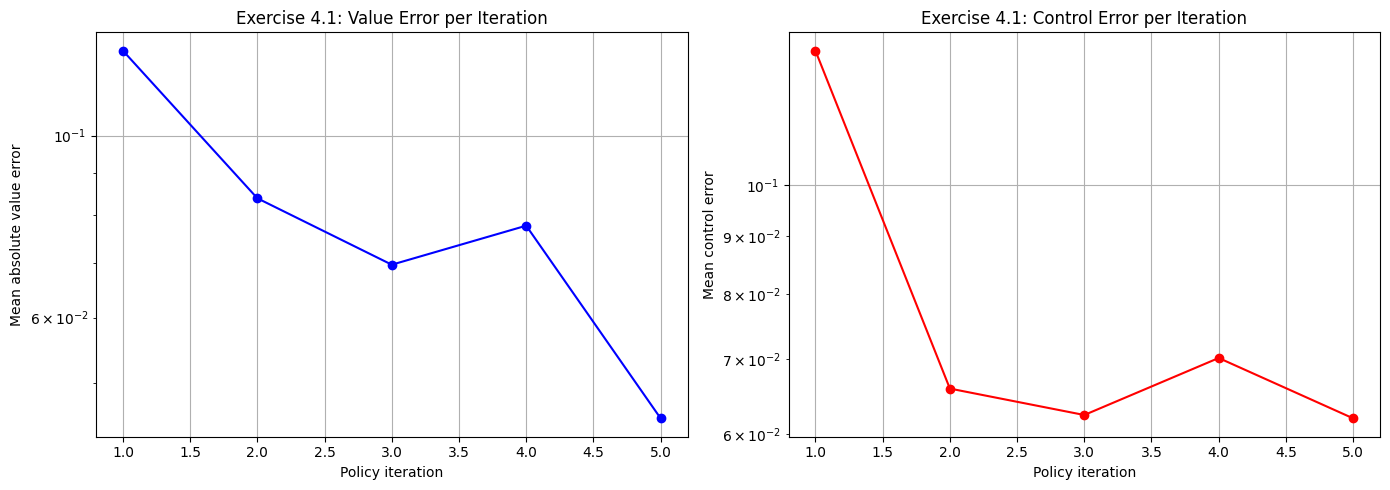


Final errors after policy iteration:
  Value function: 4.5238e-02
  Control:        6.1962e-02


In [11]:
net_val, net_act, err_val, err_act = train_policy_iteration(
        lqr,
        n_iterations=5,
        n_epochs_val=300,
        n_epochs_act=200,
        batch_size=128,
        lr=1e-3,
        initial_value_net=value_net,
        initial_control_net=control_net,
)

print("\nFinal errors after policy iteration:")
print(f"  Value function: {err_val[-1]:.4e}")
print(f"  Control:        {err_act[-1]:.4e}")